In [1]:
# import packages
using LinearAlgebra
using DifferentialEquations
using StaticArrays
using Plots
include("flemish-fish.jl")

# declare variables
Ca = 59.187
Cd = 9.57
Ea = 21179.6
Ed = 16473
eps = 0.5
rho_emp = 7164
rho_sat = 7259
R = 8.314
Aa = 10.7
Ba = 3704.6
Ad = 10.57
Bd = 3704.6
Ta = 301.15
Td = 305.15
Pas = [10., 15., 20.]
Pds = [1.5, 1.75, 2.]
Pref = 10
Peqa = Pref * exp((Aa - Ba / Ta))
Peqd = Pref * exp((Ad - Bd / Td))
uxs = [0.1, 1., 10.]
D = 1.
L = 0.8;

## 1D Reactor Models with A-Priori Given Axial Velocity 

### Steady-State Model: Convection-Diffusion Equation for Gas Density

<b>Absorption, Dirichlet Boundary Conditions<b>

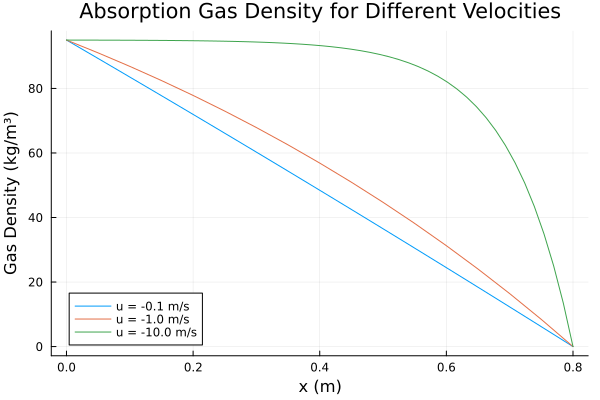

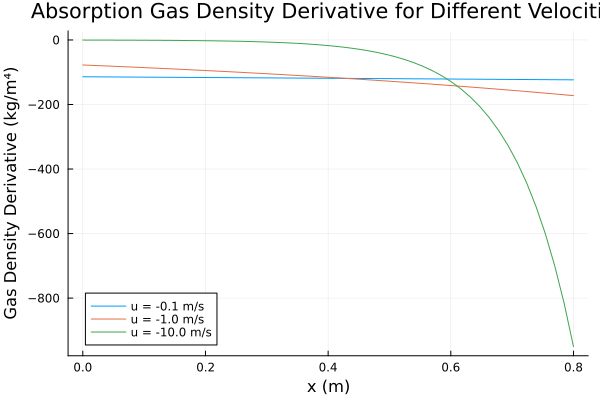

In [11]:
plt1 = plot(title="Absorption Gas Density for Different Velocities", xlabel="x (m)", ylabel="Gas Density (kg/m³)")
plt2 = plot(title="Absorption Gas Density Derivative for Different Velocities", xlabel="x (m)", ylabel="Gas Density Derivative (kg/m⁴)")

for ux in -uxs
    # problem set-up: rhs function that defines the ODE
    function rhs(du, u, p, x)
    rho_g = u[1]; drho_g = u[2]
    du[1] = drho_g
    du[2] = - ux / D * drho_g
    end

    # set boundary conditions
    function bc(residual, u, p, x)
        rho_gleft = rho_sat - rho_emp; rho_gright=0.
        residual[1] = u[1][1] - rho_gleft 
        residual[2] = u[end][1] - rho_gright
    end

    # set constants 
    p = [1]

    # set domain size 
    xspan = (0., L)

    # set initial guess 
    start = [0., 0.]

    # define and solve the problem 
    bvp = BVProblem(rhs, bc, start, xspan, p)
    sol = solve(bvp, MIRK4(), dt = 0.05);

    # plot rho_g(x) and drho_g/dx(x)
    rho_g  = [u[1] for u in sol.u]
    plot!(plt1, sol.t, rho_g, label="u = $ux m/s")
    drho_g = [u[2] for u in sol.u]
    plot!(plt2, sol.t, drho_g, label="u = $ux m/s")
end

display(plt1)
display(plt2)

<b>Absorption, Dirichlet and Neumann Boundary Conditions<b>

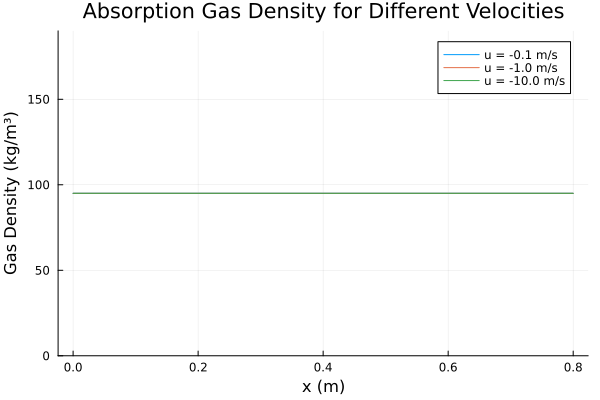

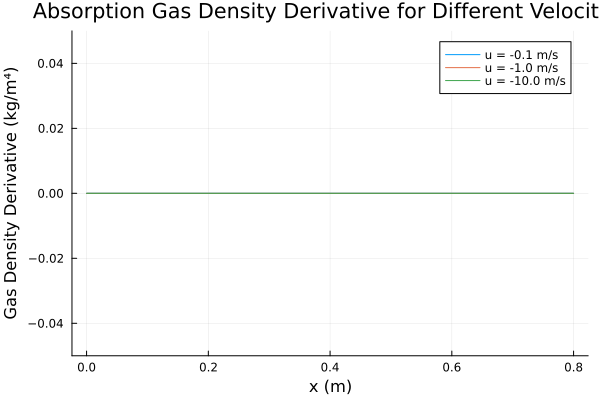

In [12]:
plt1 = plot(title="Absorption Gas Density for Different Velocities", xlabel="x (m)", ylabel="Gas Density (kg/m³)")
plt2 = plot(title="Absorption Gas Density Derivative for Different Velocities", xlabel="x (m)", ylabel="Gas Density Derivative (kg/m⁴)")

for ux in -uxs
    # problem set-up: rhs function that defines the ODE
    function rhs(du, u, p, x)
    rho_g = u[1]; drho_g = u[2]
    du[1] = drho_g
    du[2] = - ux / D * drho_g
    end

    # set boundary conditions
    function bc(residual, u, p, x)
        rho_gleft = rho_sat - rho_emp; drho_gright=0.
        residual[1] = u[1][1] - rho_gleft 
        residual[2] = u[end][2] - drho_gright
    end

    # set constants 
    p = [1]

    # set domain size 
    xspan = (0., L)

    # set initial guess 
    start = [0., 0.]

    # define and solve the problem 
    bvp = BVProblem(rhs, bc, start, xspan, p)
    sol = solve(bvp, MIRK4(), dt = 0.005);

    # plot rho_g(x) and drho_g/dx(x)
    rho_g  = [u[1] for u in sol.u]
    plot!(plt1, sol.t, rho_g, label="u = $ux m/s")
    ylims!(0., 2 * (rho_sat - rho_emp))
    drho_g = [u[2] for u in sol.u]
    plot!(plt2, sol.t, drho_g, label="u = $ux m/s")
    ylims!(-0.05, 0.05)
end

display(plt1)
display(plt2)

<b>Desorption, Dirichlet Boundary Conditions<b>

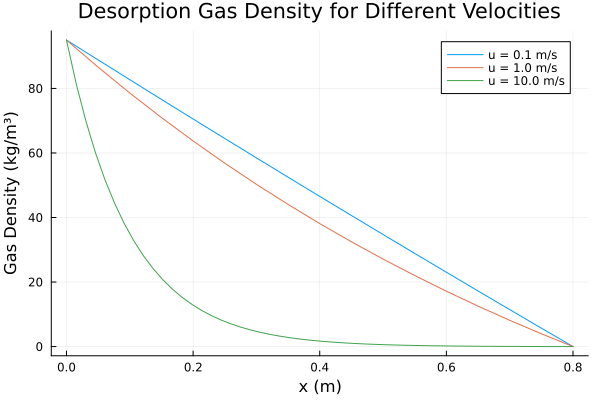

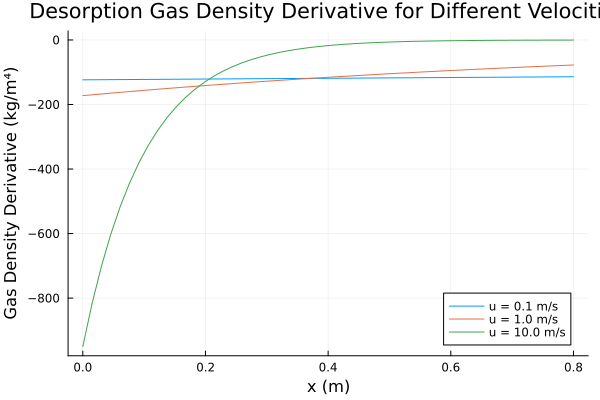

In [4]:
plt1 = plot(title="Desorption Gas Density for Different Velocities", xlabel="x (m)", ylabel="Gas Density (kg/m³)")
plt2 = plot(title="Desorption Gas Density Derivative for Different Velocities", xlabel="x (m)", ylabel="Gas Density Derivative (kg/m⁴)")

for ux in uxs
    # problem set-up: rhs function that defines the ODE
    function rhs(du, u, p, x)
    rho_g = u[1]; drho_g = u[2]
    du[1] = drho_g
    du[2] = - ux / D * drho_g
    end

    # set boundary conditions
    function bc(residual, u, p, x)
        rho_gleft = rho_sat - rho_emp; rho_gright=0.
        residual[1] = u[1][1] - rho_gleft 
        residual[2] = u[end][1] - rho_gright
    end

    # set constants 
    p = [1]

    # set domain size 
    xspan = (0., L)

    # set initial guess 
    start = [0., 0.]

    # define and solve the problem 
    bvp = BVProblem(rhs, bc, start, xspan, p)
    sol = solve(bvp, MIRK4(), dt = 0.05);

    # plot rho_g(x) and drho_g/dx(x)
    rho_g  = [u[1] for u in sol.u]
    plot!(plt1, sol.t, rho_g, label="u = $ux m/s")
    drho_g = [u[2] for u in sol.u]
    plot!(plt2, sol.t, drho_g, label="u = $ux m/s")
end

display(plt1)
display(plt2)

<b>Desorption, Dirichlet and Neumann Boundary Conditions<b>

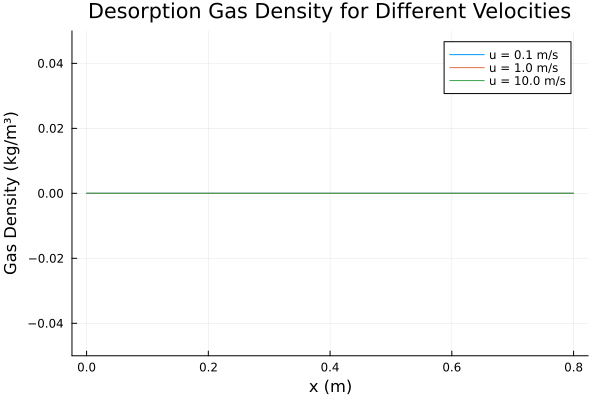

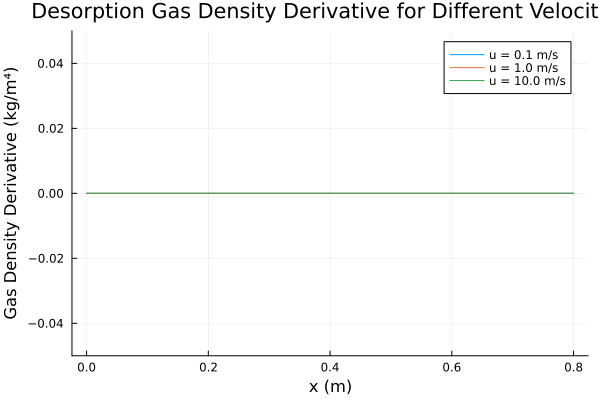

In [5]:
plt1 = plot(title="Desorption Gas Density for Different Velocities", xlabel="x (m)", ylabel="Gas Density (kg/m³)")
plt2 = plot(title="Desorption Gas Density Derivative for Different Velocities", xlabel="x (m)", ylabel="Gas Density Derivative (kg/m⁴)")

for ux in uxs
    # problem set-up: rhs function that defines the ODE
    function rhs(du, u, p, x)
    rho_g = u[1]; drho_g = u[2]
    du[1] = drho_g
    du[2] = - ux / D * drho_g
    end

    # set boundary conditions
    function bc(residual, u, p, x)
        drho_gleft = 0.; rho_gright=0.
        residual[1] = u[1][2] - drho_gleft 
        residual[2] = u[end][1] - rho_gright
    end

    # set constants 
    p = [1]

    # set domain size 
    xspan = (0., L)

    # set initial guess 
    start = [0., 0.]

    # define and solve the problem 
    bvp = BVProblem(rhs, bc, start, xspan, p)
    sol = solve(bvp, MIRK4(), dt = 0.005);

    # plot rho_g(x) and drho_g/dx(x)
    rho_g  = [u[1] for u in sol.u]
    plot!(plt1, sol.t, rho_g, label="u = $ux m/s")
    ylims!(-0.05, 0.05)
    drho_g = [u[2] for u in sol.u]
    plot!(plt2, sol.t, drho_g, label="u = $ux m/s")
    ylims!(-0.05, 0.05)
end

display(plt1)
display(plt2)

### Transient Model: Coupled Reaction-Convection-Diffusion for Solid Density and Gas Density

<b>Absorption, Dirichlet and Neumann Boundary Conditions<b>

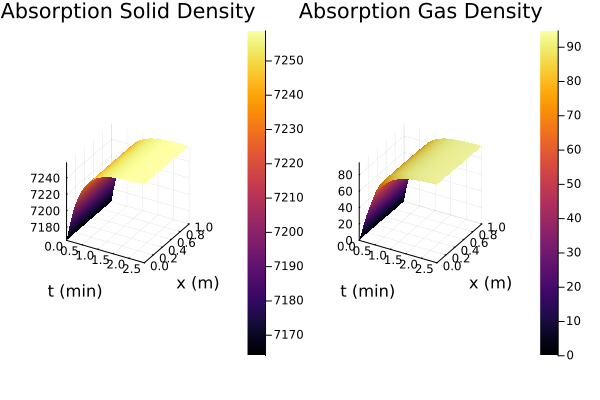

uₓ = -10.0, P = 10.0

In [ ]:
# spatial discretization 
N = (10,); Np1 = N[1]+1
m = fdmmesh(N)
K = -1 * stiffmat(m)
C = convectionmat(m);

# account for dirichlet boundary condition
K[1, :] .= 0
K[1, 1] = 1
C[1, :] .= 0

# account for neumann boundary condition
K[end, :] .= 0
K[end, end] = 1
K[end, end-1] = -1
C[end, :] .= 0
C[end, end] = 1
C[end, end-1] = -1

# choose variables
ux = -uxs[3]     # uxs = [0.1, 1., 10.]
Pa = Pas[1]     # Pas = [10., 15., 20.]
print(String("uₓ = $(ux), P = $(Pa)"))

# ODE model functions
function plug_flow_reactor!(du,u,p,t)
    Np1 = length(u) ÷ 2 
    rho_s = @view u[1:Np1]
    rho_g = @view u[Np1+1:end]
    rho_g[1] = rho_s[1] - rho_emp
    mdot = Ca * exp(-Ea / (R * Ta)) * log(Pa / Peqa) * (rho_sat .- rho_s)
    du[1:Np1] .= mdot / (1 - eps) 
    du[Np1+1:end] .= (D * K * rho_g + ux * C * rho_g .+ mdot) / eps
    du[Np1+1] = 0
end

# set constants 
p = [1]

# set initial conditions 
rho_s0 = [rho_emp for xi in m[1]]
rho_g0 = [0. for xi in m[1]]
u0  = [rho_s0; rho_g0]

# set time interval 
tspan = (0.0,150)

# define and solve the problem 
prob = ODEProblem(plug_flow_reactor!,u0,tspan,p)
sol = solve(prob, AutoVern7(Rodas5()), reltol = 1e-5, abstol = 1e-5, save_everystep = true);

# post-processing 
rho_smat = reduce(hcat,[uti[1:Np1] for uti in sol.u])
rho_gmat = reduce(hcat,[uti[Np1+1:end] for uti in sol.u])

p1 = surface(sol.t/60,m[1],rho_smat,xlabel="t (min)", ylabel="x (m)",title="Absorption Solid Density")
p2 = surface(sol.t/60,m[1],rho_gmat,xlabel="t (min)", ylabel="x (m)",title="Absorption Gas Density")
plt = plot(p1,p2,layout=(1,2))
display(plt)

<b>Desorption, Dirichlet and Neumann Boundary Conditions<b>

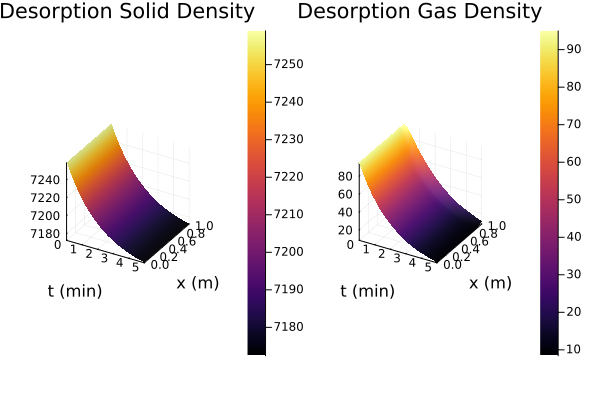

uₓ = 10.0, P = 1.5

In [ ]:
# spatial discretization 
N = (10,); Np1 = N[1]+1
m = fdmmesh(N)
K = -1 * stiffmat(m)
C = convectionmat(m);

# account for neumann boundary condition
K[1, :] .= 0
K[1, 1] = 1
K[1, 2] = -1
C[1, :] .= 0
C[1, 1] = 1
C[1, 2] = -1

# account for dirichlet boundary condition
K[end, :] .= 0
K[end, end] = 1
C[end, :] .= 0

# choose variables
ux = uxs[3]   # uxs = [0.1, 1., 10.]
Pd = Pds[1]     # Pds = [1.5, 1.75, 2.]
print(String("uₓ = $(ux), P = $(Pd)"))

# ODE model functions
function plug_flow_reactor!(du,u,p,t)
    Np1 = length(u) ÷ 2 
    rho_s = @view u[1:Np1]
    rho_g = @view u[Np1+1:end]
    rho_g[end] = rho_s[end] - rho_emp
    mdot = Cd * exp(-Ed / (R * Td)) * (Pd - Peqd) / Peqd * (rho_s .- rho_emp)
    du[1:Np1] .= mdot / (1 - eps) 
    du[Np1+1:end] .= (D * K * rho_g + ux * C * rho_g .+ mdot) / eps
    du[end] = 0
end

# set constants 
p = [1]

# set initial conditions 
rho_s0 = [rho_sat for xi in m[1]]
rho_g0 = [rho_sat - rho_emp for xi in m[1]]
u0  = [rho_s0; rho_g0]

# set time interval 
tspan = (0.0,300)

# define and solve the problem 
prob = ODEProblem(plug_flow_reactor!,u0,tspan,p)
sol = solve(prob, AutoVern7(Rodas5()), reltol = 1e-5, abstol = 1e-5, save_everystep = true);

# post-processing 
rho_smat = reduce(hcat,[uti[1:Np1] for uti in sol.u])
rho_gmat = reduce(hcat,[uti[Np1+1:end] for uti in sol.u])

p1 = surface(sol.t/60,m[1],rho_smat,xlabel="t (min)", ylabel="x (m)",title="Desorption Solid Density")
p2 = surface(sol.t/60,m[1],rho_gmat,xlabel="t (min)", ylabel="x (m)",title="Desorption Gas Density")
plt = plot(p1,p2,layout=(1,2))
display(plt)